# Google Drive

In [1]:
# Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports

In [2]:
# Imports
import os
import zipfile
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

# Prepare and Extract Dataset

In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/DSAI490_Assignment1/data/raw/archive.zip"
extract_path = "/content/drive/MyDrive/DSAI490_Assignment1/data/raw/medical_mnist"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    # zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [4]:
dataset_path = "/content/drive/MyDrive/DSAI490_Assignment1/data/raw/medical_mnist"
print(os.listdir(dataset_path))

['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']


In [5]:
from pathlib import Path
print(os.listdir(Path(extract_path).parent))

['archive.zip', 'medical_mnist']


# Load Dataset using tf.data

In [6]:
# Load Dataset using tf.data
IMG_SIZE = 64
BATCH_SIZE = 32

# Dir for BreastMRI
data_dir = os.path.join(extract_path, "BreastMRI")

# Preprocessing

In [7]:
# Preprocessing
def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

file_paths = tf.data.Dataset.from_tensor_slices(
    [os.path.join(data_dir, fname) for fname in os.listdir(data_dir)]
)

dataset = file_paths.map(preprocess_image)

dataset = dataset.map(lambda x: (x, x))

dataset = dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

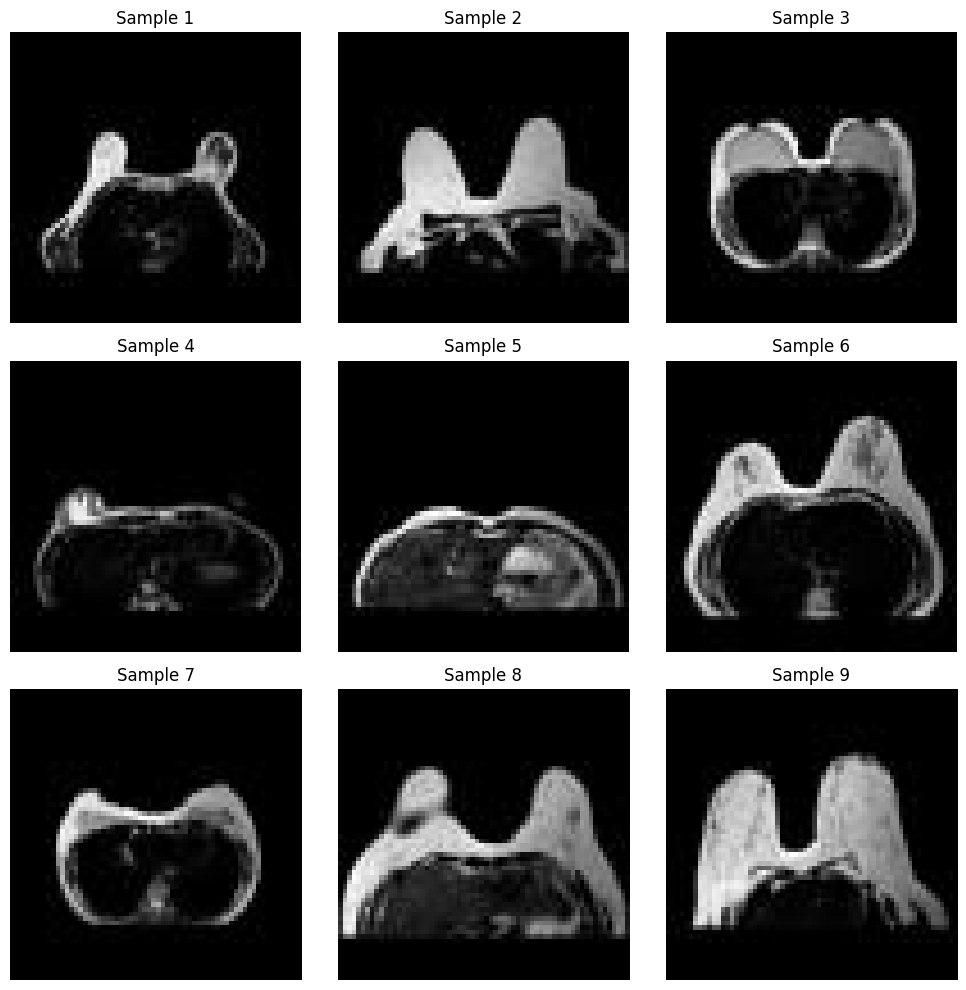

In [ ]:
# Show Samples
import matplotlib.pyplot as plt

# Take one batch from the dataset
for images, _ in dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, BATCH_SIZE)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(f"Sample {i+1}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Autoencoder Model (AE)

In [ ]:
# Autoencoder Model
LATENT_DIM = 32

# Encoder
encoder_inputs = layers.Input(shape=(64,64,1))

x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2D(128,3,strides=2,padding="same",activation="relu")(x)

shape_before_flatten = K.int_shape(x)[1:]

x = layers.Flatten()(x)
latent = layers.Dense(LATENT_DIM, name="latent_vector")(x)

encoder = Model(encoder_inputs, latent, name="encoder")
encoder.summary()

# Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))

x = layers.Dense(int(np.prod(shape_before_flatten)))(latent_inputs)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.Conv2DTranspose(128,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)

decoder_outputs = layers.Conv2DTranspose(
    1,3,padding="same",activation="sigmoid"
)(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

# Autoencoder
ae_inputs = encoder_inputs
encoded = encoder(ae_inputs)
decoded = decoder(encoded)

autoencoder = Model(ae_inputs, decoded, name="autoencoder")
autoencoder.compile( optimizer="adam", loss="mse")

autoencoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 32)             │       262,176 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,848 (1.35 MB)

 Trainable params: 354,848 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       354,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 1)      │       510,465 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865,313 (3.30 MB)

 Trainable params: 865,313 (3.30 MB)

 Non-trainable params: 0 (0.00 B)

# Training

In [ ]:
# Train AE
history_ae = autoencoder.fit(dataset, epochs=10)

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 147s 499ms/step - loss: 0.0390
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 146s 508ms/step - loss: 0.0138
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 140s 489ms/step - loss: 0.0089
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 137s 476ms/step - loss: 0.0069
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 143s 499ms/step - loss: 0.0056
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 147s 511ms/step - loss: 0.0049
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 142s 496ms/step - loss: 0.0043
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 141s 493ms/step - loss: 0.0040
Epoch 9/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 140s 488ms/step - loss: 0.0036
Epoch 10/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 139s 484ms/step - loss: 0.0034


# Autoencoder Loss Plot

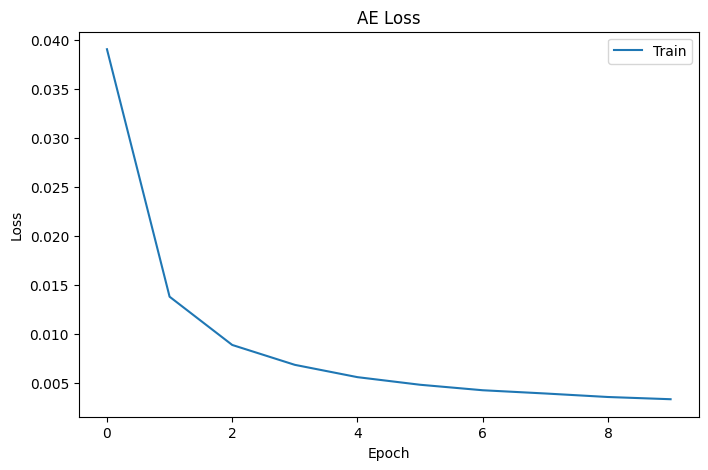

In [ ]:
# AE Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history_ae.history["loss"], label="Train")

# Plot validation loss only if it exists in the history
if "val_loss" in history_ae.history:
    plt.plot(history_ae.history["val_loss"], label="Validation")

plt.title("AE Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Autoencoder Reconstruction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


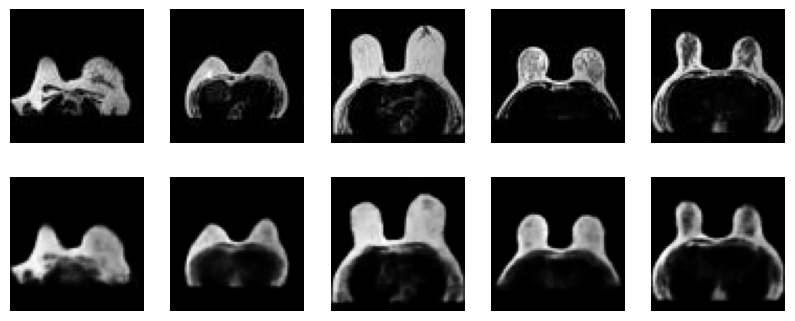

In [ ]:
# AE Reconstruction
def show_reconstruction(model, dataset):
    for batch in dataset.take(1):
        inputs, _ = batch

        recon = model.predict(inputs)

        plt.figure(figsize=(10, 4))
        for i in range(5):
            # Original
            plt.subplot(2, 5, i+1)
            plt.imshow(inputs[i], cmap='gray')
            plt.axis('off')

            # Reconstructed
            plt.subplot(2, 5, i+6)
            plt.imshow(recon[i], cmap='gray')
            plt.axis('off')

        plt.show()

show_reconstruction(autoencoder, dataset)

# Variational Autoencoder (VAE)

In [ ]:
# Variational Autoencoder VAE
LATENT_DIM = 2

# Encoder
inputs = layers.Input(shape=(64,64,1))

x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(inputs)
x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2D(128,3,strides=2,padding="same",activation="relu")(x)

shape_before_flatten = K.int_shape(x)[1:]

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM)(x)
z_log_var = layers.Dense(LATENT_DIM)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], LATENT_DIM))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder_vae = Model(inputs, [z_mean, z_log_var, z], name="vae_encoder")

# Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))
x = layers.Dense(int(np.prod(shape_before_flatten)))(latent_inputs)
x = layers.Reshape(shape_before_flatten)(x)

x = layers.Conv2DTranspose(128,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
x = layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)

outputs = layers.Conv2DTranspose(1,3,padding="same",activation="sigmoid")(x)

decoder_vae = Model(latent_inputs, outputs, name="vae_decoder")

In [ ]:
# Custom VAE Model
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        x, _ = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x)

            reconstruction = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(x, reconstruction),
                    axis=(1,2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss
        }

vae = VAE(encoder_vae, decoder_vae)
vae.compile(optimizer="adam")

# Training

In [ ]:
# Train VAE
history_vae = vae.fit(dataset, epochs=10)

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 151s 510ms/step - kl_loss: 6.2731 - loss: 812.6653 - reconstruction_loss: 806.3922
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 145s 507ms/step - kl_loss: 6.1133 - loss: 805.7755 - reconstruction_loss: 799.6622
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 144s 502ms/step - kl_loss: 6.1139 - loss: 842.2318 - reconstruction_loss: 836.1179
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 148s 517ms/step - kl_loss: 6.5285 - loss: 870.0240 - reconstruction_loss: 863.4955
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 145s 507ms/step - kl_loss: 6.0904 - loss: 800.3010 - reconstruction_loss: 794.2106
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 202s 505ms/step - kl_loss: 6.1660 - loss: 854.5348 - reconstruction_loss: 848.3688
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 202s 507ms/step - kl_loss: 7.6250 - loss: 814.8337 - reconstruction_loss: 807.2087
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 157s 550ms/step - kl_loss: 6.3468 - loss: 757.8770 - reconstruction_loss: 751.5302
Epoch 9/10
280/2

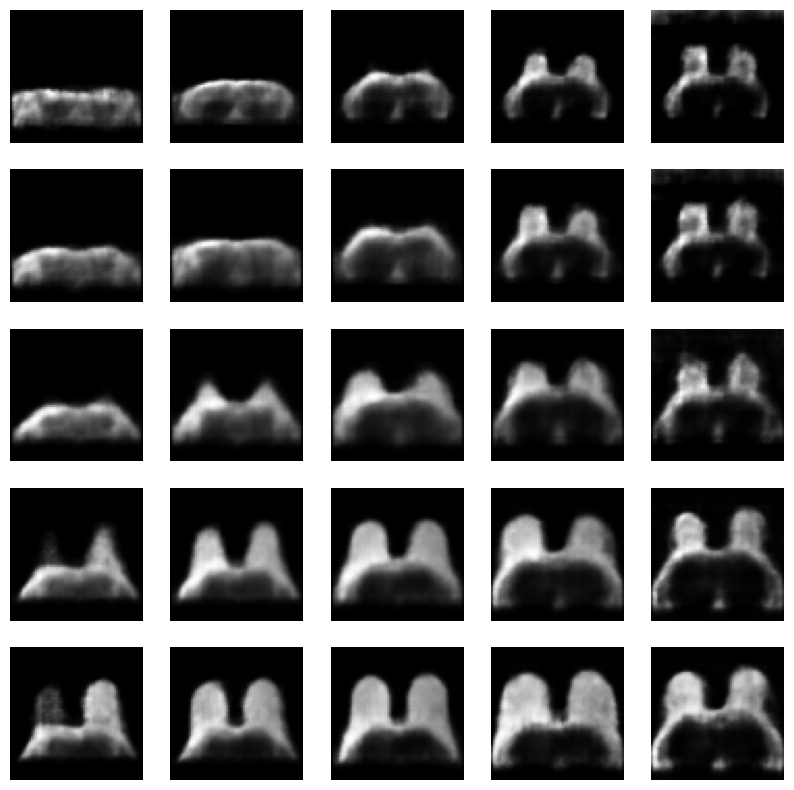

In [ ]:
# Generate Samples from VAE
grid_x = np.linspace(-2,2,5)
grid_y = np.linspace(-2,2,5)

plt.figure(figsize=(10,10))

count = 1
for yi in grid_y:
    for xi in grid_x:
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder_vae.predict(z_sample, verbose=0)

        plt.subplot(5,5,count)
        plt.imshow(x_decoded[0].squeeze(), cmap='gray')
        plt.axis("off")
        count += 1

plt.show()

# Variational Autoencoder Loss Plot

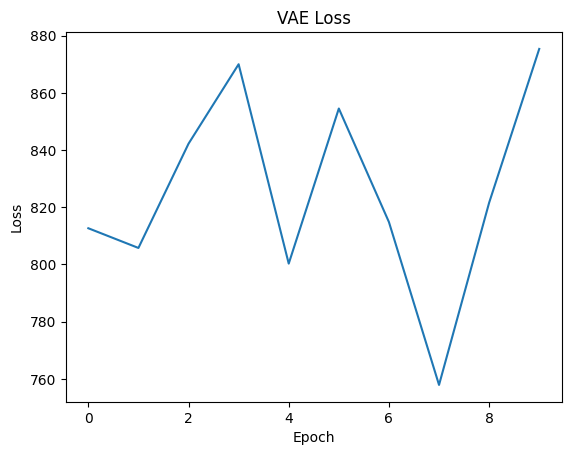

In [ ]:
# VAE Loss Plot
def plot_loss(history, title):
    plt.plot(history.history['loss'])
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

plot_loss(history_vae, "VAE Loss")

# Latent Space Visualization

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━

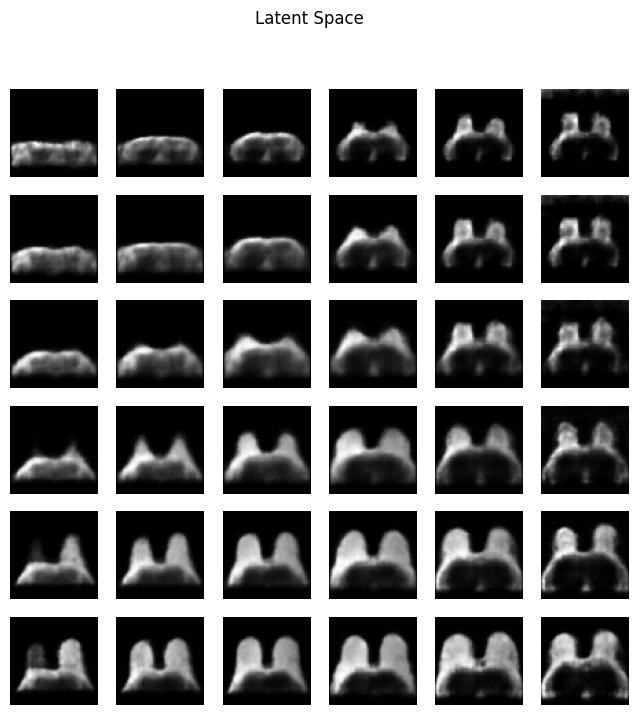

In [ ]:
# Latent Space
def latent(decoder, grid_size=6):
    grid_x = np.linspace(-2, 2, grid_size)
    grid_y = np.linspace(-2, 2, grid_size)

    plt.figure(figsize=(8,8))

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = np.array([[xi, yi]])
            img = decoder.predict(z)[0]

            plt.subplot(grid_size, grid_size, i * grid_size + j + 1)
            plt.imshow(img, cmap='gray')
            plt.axis('off')

    plt.suptitle("Latent Space")
    plt.show()

latent(decoder_vae)

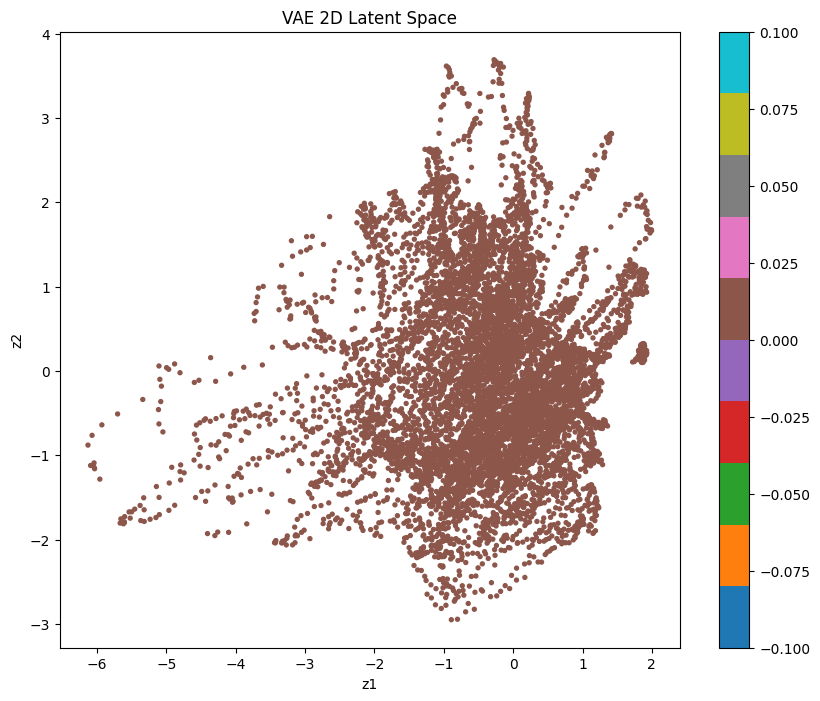

In [ ]:
# 2D Latent Space Visualization
latent_vectors = []
labels_all = []

for batch_input_images, _ in dataset:
    # Predict the latent space mean using the VAE encoder
    z_mean, _, _ = encoder_vae.predict(batch_input_images, verbose=0)
    latent_vectors.append(z_mean)

    # The dataset currently only loads images from BreastMRI
    labels_all.append(np.zeros(batch_input_images.shape[0]))

# Concatenate all collected latent vectors and labels
latent_vectors = np.concatenate(latent_vectors)
labels_all = np.concatenate(labels_all)

plt.figure(figsize=(10,8))
scatter = plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    c=labels_all,
    cmap='tab10',
    s=8
)

plt.colorbar(scatter)
plt.title("VAE 2D Latent Space")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

# AE vs VAE Reconstruction Comparison

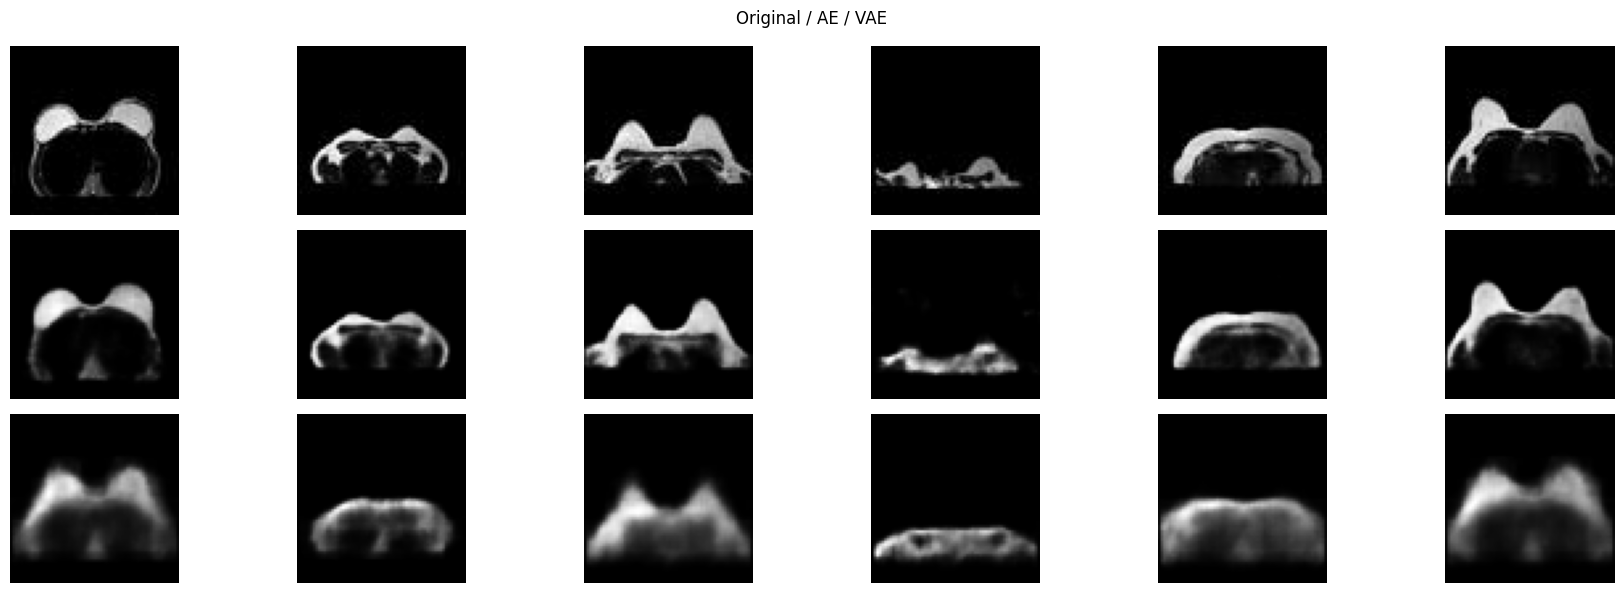

In [ ]:
# AE vs VAE Reconstruction Comparison
for batch_images, _ in dataset.take(1):

    ae_preds = autoencoder.predict(batch_images[:6], verbose=0)

    z_mean, _, z = encoder_vae.predict(batch_images[:6], verbose=0)
    vae_preds = decoder_vae.predict(z, verbose=0)

    plt.figure(figsize=(18,6))

    for i in range(6):

        # Original
        plt.subplot(3,6,i+1)
        plt.imshow(batch_images[i].numpy().squeeze(), cmap='gray')
        plt.axis("off")

        # AE
        plt.subplot(3,6,i+7)
        plt.imshow(ae_preds[i].squeeze(), cmap='gray')
        plt.axis("off")

        # VAE
        plt.subplot(3,6,i+13)
        plt.imshow(vae_preds[i].squeeze(), cmap='gray')
        plt.axis("off")

plt.suptitle("Original / AE / VAE")
plt.tight_layout()
plt.show()

In [ ]:
# AE vs VAE
ae_loss = autoencoder.evaluate(dataset, verbose=0)

print("AE Validation Loss:", ae_loss)

# For VAE approximate reconstruction loss
for batch_images, _ in dataset.take(1):
    z_mean, _, z = encoder_vae.predict(batch_images, verbose=0)
    vae_preds = decoder_vae.predict(z, verbose=0)

    mse = np.mean((batch_images.numpy() - vae_preds) ** 2)
    print("VAE Reconstruction MSE:", mse)

AE Validation Loss: 0.003399650566279888
VAE Reconstruction MSE: 0.017858382


# Denoising Autoencoder

In [ ]:
# Denoising Autoencoder
def add_noise(x):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=0.15)
    return tf.clip_by_value(x + noise, 0.0, 1.0)

denoise_ds = dataset.map(
    lambda x, y: (add_noise(x), x)
).prefetch(tf.data.AUTOTUNE)

# Train Denoise AE
autoencoder.fit(
    denoise_ds,
    epochs=3
)

Epoch 1/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 144s 502ms/step - loss: 0.0039
Epoch 2/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 143s 497ms/step - loss: 0.0035
Epoch 3/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 147s 514ms/step - loss: 0.0034


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


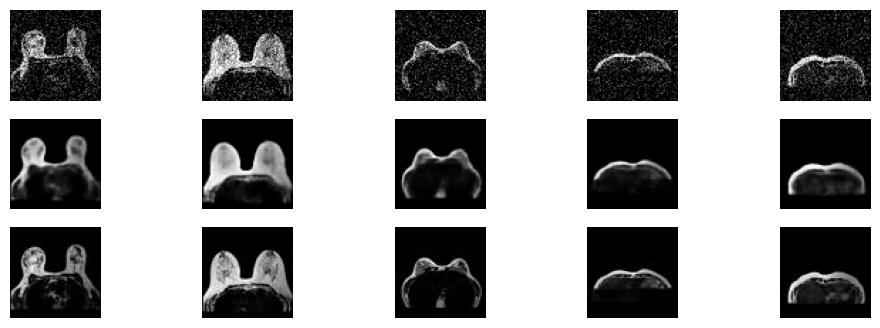

In [ ]:
import matplotlib.pyplot as plt
# Show Denoising Results
def show_denoising(model, dataset):
    for batch in dataset.take(1):
        noisy, clean = batch
        recon = model.predict(noisy)

        plt.figure(figsize=(12, 4))
        for i in range(5):
            # Noisy
            plt.subplot(3, 5, i+1)
            plt.imshow(noisy[i], cmap='gray')
            plt.axis('off')

            # Reconstructed
            plt.subplot(3, 5, i+6)
            plt.imshow(recon[i], cmap='gray')
            plt.axis('off')

            # Original
            plt.subplot(3, 5, i+11)
            plt.imshow(clean[i], cmap='gray')
            plt.axis('off')

        plt.show()

show_denoising(autoencoder, denoise_ds)

# Train on All Classes

In [8]:
# Train AE & VAE on All Classes
LATENT_DIM_AE = 32
LATENT_DIM_VAE = 2
EPOCHS = 3

In [9]:
# Preprocessing
def preprocess_image(file_path):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def create_dataset(folder_path):
    file_list = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    dataset = tf.data.Dataset.from_tensor_slices(file_list)
    dataset = dataset.map(preprocess_image)
    dataset = dataset.map(lambda x: (x, x))
    dataset = dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

# AE

In [10]:
# Autoencoder
def build_ae(latent_dim=32):

    # Encoder
    encoder_inputs = layers.Input(shape=(64,64,1))

    x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
    x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)

    x = layers.Flatten()(x)
    latent = layers.Dense(latent_dim)(x)

    encoder = Model(encoder_inputs, latent)

    # Decoder
    latent_inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(16*16*64, activation="relu")(latent_inputs)
    x = layers.Reshape((16,16,64))(x)

    x = layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
    x = layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)

    outputs = layers.Conv2D(1,3,padding="same",activation="sigmoid")(x)

    decoder = Model(latent_inputs, outputs)

    # AE
    outputs = decoder(encoder(encoder_inputs))

    autoencoder = Model(encoder_inputs, outputs)
    autoencoder.compile(optimizer="adam", loss="mse")

    return autoencoder

# VAE

In [11]:
# Variational Autoencoder
def build_vae(latent_dim=2):

    # Encoder
    encoder_inputs = layers.Input(shape=(64,64,1))

    x = layers.Conv2D(32,3,strides=2,padding="same",activation="relu")(encoder_inputs)
    x = layers.Conv2D(64,3,strides=2,padding="same",activation="relu")(x)

    x = layers.Flatten()(x)

    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)

    def sampling(args):
        z_mean, z_log_var = args
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    encoder = Model(encoder_inputs, [z_mean, z_log_var, z])

    # Decoder
    latent_inputs = layers.Input(shape=(latent_dim,))

    x = layers.Dense(16*16*64, activation="relu")(latent_inputs)
    x = layers.Reshape((16,16,64))(x)

    x = layers.Conv2DTranspose(64,3,strides=2,padding="same",activation="relu")(x)
    x = layers.Conv2DTranspose(32,3,strides=2,padding="same",activation="relu")(x)

    outputs = layers.Conv2D(1,3,padding="same",activation="sigmoid")(x)

    decoder = Model(latent_inputs, outputs)

    # Custom VAE
    class VAE(Model):

        def __init__(self, encoder, decoder):
            super().__init__()
            self.encoder = encoder
            self.decoder = decoder

        def call(self, inputs):

            z_mean, z_log_var, z = self.encoder(inputs)
            reconstructed = self.decoder(z)

            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.mse(inputs, reconstructed),
                    axis=(1,2)
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            self.add_loss(recon_loss + kl_loss)

            return reconstructed

    vae = VAE(encoder, decoder)
    vae.compile(optimizer="adam")

    return vae

In [14]:
regions = os.listdir(extract_path)
results = {}

for region in regions:

    print(f" Training for Region: {region}")

    region_path = os.path.join(extract_path, region)

    if not os.path.isdir(region_path):
        continue

    file_list = [
        os.path.join(region_path, f)
        for f in os.listdir(region_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if not file_list:
        print(f" No image files found in {region_path}. Skipping this region.")
        continue

    dataset = create_dataset(region_path)

    try:
        # AE
        print("Training Autoencoder")
        ae = build_ae(LATENT_DIM_AE)
        history_ae = ae.fit(dataset, epochs=EPOCHS, verbose=1)

        # VAE
        print("Training Variational Autoencoder")
        vae = build_vae(LATENT_DIM_VAE)
        history_vae = vae.fit(dataset, epochs=EPOCHS, verbose=1)

        results[region] = {
            "AE": ae,
            "VAE": vae,
            "AE_History": history_ae,
            "VAE_History": history_vae
        }
    except tf.errors.InvalidArgumentError as e:
        print(f"  Error during training for region {region}: {e}. Skipping this region.")
    except Exception as e:
        print(f"  An unexpected error occurred during training for region {region}: {e}. Skipping this region.")

 Training for Region: AbdomenCT
Training Autoencoder
Epoch 1/3
  Error during training for region AbdomenCT: Graph execution error:

Detected at node DecodePng defined at (most recent call last):
<stack traces unavailable>
Error in user-defined function passed to MapDataset:21 transformation with iterator: Iterator::Root::Prefetch::BatchV2::Shuffle::ParallelMapV2::ParallelMapV2: Input is empty.
	 [[{{node DecodePng}}]]
	 [[IteratorGetNext]] [Op:__inference_multi_step_on_iterator_7835]. Skipping this region.
 Training for Region: BreastMRI
Training Autoencoder
Epoch 1/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 223s 248ms/step - loss: 0.0380
Epoch 2/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 69s 237ms/step - loss: 0.0112
Epoch 3/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 69s 238ms/step - loss: 0.0073
Training Variational Autoencoder
Epoch 1/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 71s 239ms/step - loss: 139.8722
Epoch 2/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 69s 237ms/step - loss: 83.0583
Epoch 3/3
280/280 ━━━━━━━━━━━━━━━━━━━━ 84s 245ms/ste

In [15]:
# Loss Visualization
def plot_loss(history, title):
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"])
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

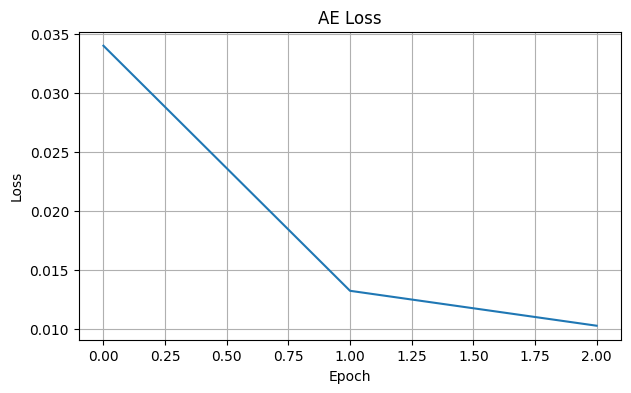

In [16]:
# Show AE trained region
plot_loss(history_ae, "AE Loss")

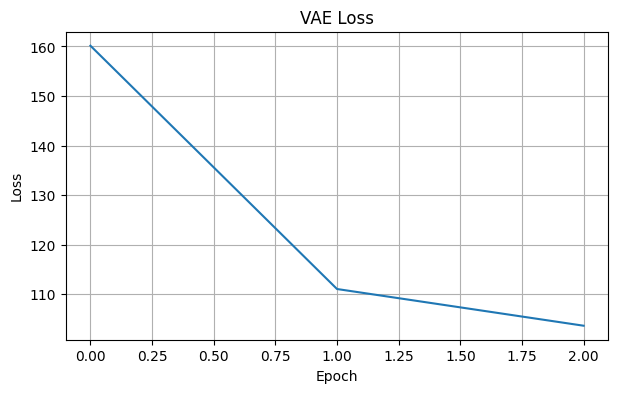

In [17]:
# Show VAE trained region
plot_loss(history_vae, "VAE Loss")